<a href="https://colab.research.google.com/github/yastreb13/dzdlmfti/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0__AI_Edu_Modern_CV_Homework_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Education. Современное компьютерное зрение
# Домашнее задание 2

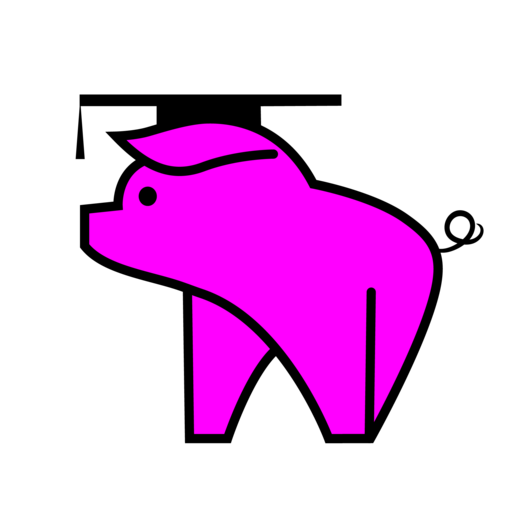

В этом домашнем задании вам предстоит реализовать и обучить сеть EfficientNetV2-Small.

### Класс блока MB-Conv и модели EfficientNetV2-Small (5 баллов)

На семинаре мы с вами написали MBConv блок, его код представлен ниже. Напишите Fused-MBConv блок и составьте саму модель EfficientNetV2-Small из этих блоков и дополнительных слоев. (5 баллов)

Примечание: Архитектуру можно найти в статье https://arxiv.org/pdf/2104.00298v3 (см. таблица 4, фигура 2) или на изображениях ниже

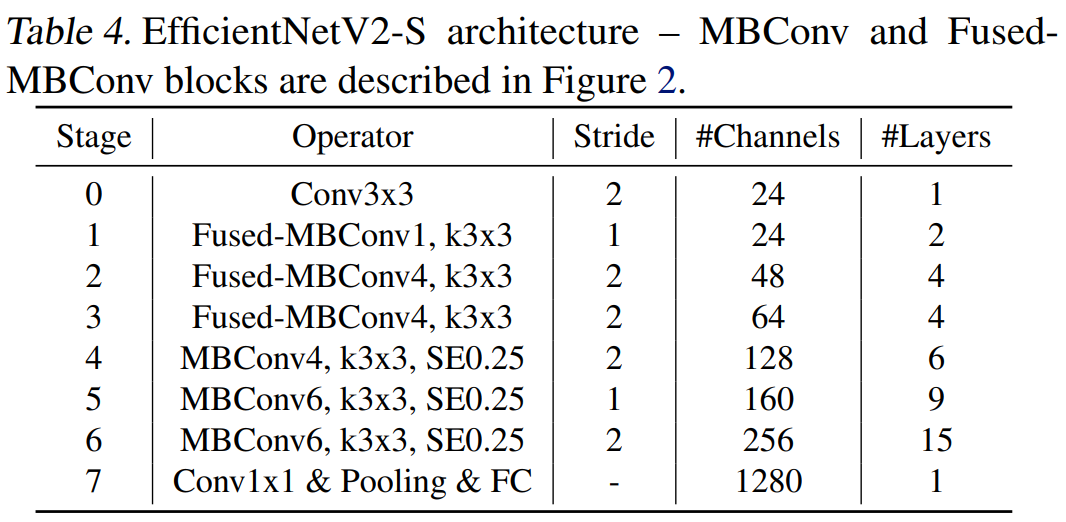

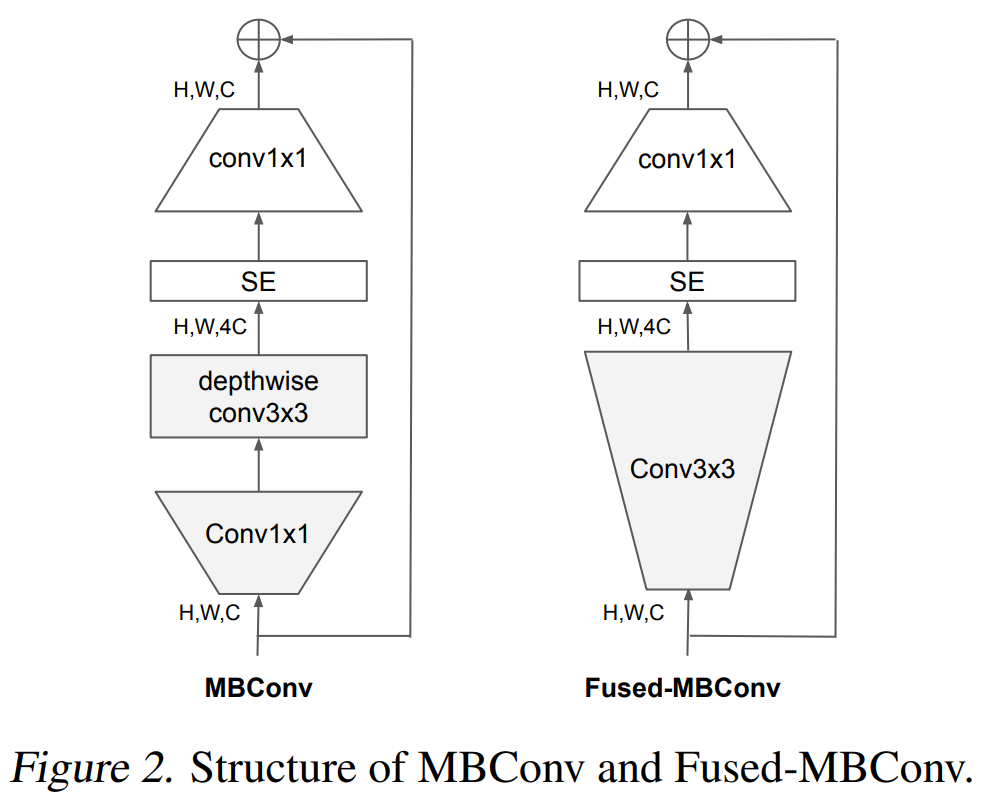

In [ ]:
import gc
import torch

# 1. Удаляем старые ссылки на модель и данные (если они зависли в ячейках)
if "model" in locals():
    del model
if "inputs" in locals():
    del inputs
if "outputs" in locals():
    del outputs

# 2. Принудительно запускаем сборщик мусора Python
gc.collect()

# 3. Полностью очищаем кэш аллокатора CUDA
torch.cuda.empty_cache()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from torch.utils.data import Dataset, DataLoader
import os
from PIL import Image
import pandas as pd

In [ ]:
class MBConv(nn.Module):
    def __init__(self, in_channels, out_channels, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25):
        super(MBConv, self).__init__()
        hidden_dim = in_channels * expansion_factor
        self.use_residual = in_channels == out_channels and stride == 1

        # Expansion
        self.expand = nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False) if expansion_factor > 1 else None
        self.bn1 = nn.BatchNorm2d(hidden_dim) if expansion_factor > 1 else None

        # Depthwise Convolution
        self.depthwise = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=kernel_size, stride=stride,
                                   padding=kernel_size//2, groups=hidden_dim, bias=False)
        self.bn2 = nn.BatchNorm2d(hidden_dim)

        # Squeeze-and-Excitation
        se_hidden_dim = max(1, int(in_channels * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(hidden_dim, se_hidden_dim, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(se_hidden_dim, hidden_dim, kernel_size=1),
            nn.Sigmoid()
        ) if se_ratio > 0 else None

        # Projection
        self.project = nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = x

        if self.expand:
            out = F.relu6(self.bn1(self.expand(out)))

        out = F.relu6(self.bn2(self.depthwise(out)))

        if self.se:
            out = out * self.se(out)

        out = self.bn3(self.project(out))

        if self.use_residual:
            out = out + x

        return out

class FusedMBConv(nn.Module):
    def __init__(self, in_channels, out_channels, expansion_factor=6, kernel_size=3, stride=1, se_ratio=1):
        super(FusedMBConv, self).__init__()
        hidden_dim = in_channels * expansion_factor
        self.use_residual = in_channels == out_channels and stride == 1

        self.conv = nn.Conv2d(in_channels, hidden_dim, kernel_size=kernel_size, stride=stride, padding=kernel_size//2, bias=False)
        self.bn1 = nn.BatchNorm2d(hidden_dim)
        se_hidden_dim = max(1, int(in_channels * se_ratio))
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(hidden_dim, se_hidden_dim, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(se_hidden_dim, hidden_dim, kernel_size=1),
            nn.Sigmoid()
        )
        self.project = nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = F.relu6(self.bn1(self.conv(x)))

        if self.se:
            out = out * self.se(out)

        out = self.bn2(self.project(out))

        if self.use_residual:
            out = out + x

        return out

In [ ]:
# model_for_example=models.efficientnet_v2_s()
# print(model_for_example) неудобно


![image.png](attachment:image.png)

<table>
  <tr><th>Stage</th><th>Operator</th><th>Stride</th><th>#Channels</th><th>#Layers</th><th>Done</th></tr>
  <tr><td>0</td><td>Conv3x3</td><td>2</td><td>24</td><td>1</td><td><input type="checkbox"></td></tr>
  <tr><td>1</td><td>Fused-MBConv1, k3x3</td><td>1</td><td>24</td><td>2</td><td><input type="checkbox"></td></tr>
  <tr><td>2</td><td>Fused-MBConv4, k3x3</td><td>2</td><td>48</td><td>4</td><td><input type="checkbox"></td></tr>
  <tr><td>3</td><td>Fused-MBConv4, k3x3</td><td>2</td><td>64</td><td>4</td><td><input type="checkbox"></td></tr>
  <tr><td>4</td><td>MBConv4, k3x3, SE0.25</td><td>2</td><td>128</td><td>6</td><td><input type="checkbox"></td></tr>
  <tr><td>5</td><td>MBConv6, k3x3, SE0.25</td><td>1</td><td>160</td><td>9</td><td><input type="checkbox"></td></tr>
  <tr><td>6</td><td>MBConv6, k3x3, SE0.25</td><td>2</td><td>256</td><td>15</td><td><input type="checkbox"></td></tr>
  <tr><td>7</td><td>Conv1x1 &amp; Pooling &amp; FC</td><td>-</td><td>1280</td><td>1</td><td><input type="checkbox"></td></tr>
</table>


In [ ]:
class Reshape(nn.Module):
    def __init__(self, *args):
        super(Reshape, self).__init__()
        self.shape=args
    def forward(self, x):
        return x.view(x.size(0), *self.shape)

In [ ]:
class EfficientNetV2Small(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetV2Small, self).__init__()
        self.input_layers = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=24,kernel_size=3, stride=2)
        )

        self.blocks = nn.Sequential(
            FusedMBConv(24, 24, 1, kernel_size=3, stride=1, se_ratio=1),
            FusedMBConv(24, 24, 1, kernel_size=3, stride=1, se_ratio=1),

            FusedMBConv(24, 48, 4, kernel_size=3, stride=2, se_ratio=1),
            FusedMBConv(48, 48, 4, kernel_size=3, stride=1, se_ratio=1),
            FusedMBConv(48, 48, 4, kernel_size=3, stride=1, se_ratio=1),
            FusedMBConv(48, 48, 4, kernel_size=3, stride=1, se_ratio=1),

            FusedMBConv(48, 64, 4, kernel_size=3, stride=2, se_ratio=1),
            FusedMBConv(64, 64, 4, kernel_size=3, stride=1, se_ratio=1),
            FusedMBConv(64, 64, 4, kernel_size=3, stride=1, se_ratio=1),
            FusedMBConv(64, 64, 4, kernel_size=3, stride=1, se_ratio=1),

            MBConv(64, 128, expansion_factor=4, kernel_size=3, stride=2, se_ratio=0.25),
            MBConv(128, 128, expansion_factor=4, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(128, 128, expansion_factor=4, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(128, 128, expansion_factor=4, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(128, 128, expansion_factor=4, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(128, 128, expansion_factor=4, kernel_size=3, stride=1, se_ratio=0.25),

            MBConv(128, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(160, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(160, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(160, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(160, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(160, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(160, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(160, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(160, 160, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),

            MBConv(160, 256, expansion_factor=6, kernel_size=3, stride=2, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25),
            MBConv(256, 256, expansion_factor=6, kernel_size=3, stride=1, se_ratio=0.25)
        )

        self.output_layers = nn.Sequential(
            nn.Conv2d(256, 1280, kernel_size=1),
            nn.AdaptiveAvgPool2d(1),
            Reshape(-1), #не хотел использовать флаттен
            nn.Linear(1280,num_classes)
        )

    def forward(self, x):
        out = self.input_layers(x)
        out = self.blocks(out)
        out = self.output_layers(out)
        return out

In [ ]:
dummy1=torch.randn(1, 24, 112, 112)
dummy2=torch.randn(1, 64, 56, 56)
dummy3=torch.randn(1, 3, 224, 224)
FusedMBConv_test=FusedMBConv(in_channels=24, out_channels=48, expansion_factor=2, kernel_size=3, stride=2)
MBConv_test=MBConv(in_channels=64, out_channels=256, expansion_factor=4, kernel_size=3, stride=2)
Model_test=EfficientNetV2Small(num_classes=10)
print(len(FusedMBConv_test(dummy1))!=0)
print(len(MBConv_test(dummy2))!=0)
print(len(Model_test(dummy3))!=0)

True
True
True


### Обучение (5 баллов)

Произведите обучение модели на датасете из прошлого домашнего задания. Используйте аугментации, оптимизаторы и т.д. на свой вкус. Добейтесь val_accuracy > 0.3. (5 баллов)

Датасет: https://www.kaggle.com/datasets/akash2sharma/tiny-imagenet/data

Примечание: можете использовать процедуру обучения как у модели из прошлого дз или сразу перейти к бонусному заданию, баллы за это задание будут засчитаны в любом случае при достижении val_accuracy > 0.3.

In [ ]:
class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, transform=None, train=True):
        self.root_dir = root_dir

        self.train = train
        self.transform = transform

        if self.train:
            self.data = []
            self.labels = []
            classes = sorted(os.listdir(os.path.join(root_dir, 'train')))

            # Поиск картинок и присвоение labels
            for label, cls in enumerate(classes):
                cls_dir = os.path.join(root_dir, 'train', cls, 'images')
                for img_name in os.listdir(cls_dir):
                    self.data.append(os.path.join(cls_dir, img_name)) # store the path only
                    self.labels.append(label)
        else:
            self.data = []
            self.labels = []
            val_dir = os.path.join(root_dir, 'val', 'images')

            # Чтение csv файлов с данными
            val_annotations = pd.read_csv(os.path.join(root_dir, 'val', 'val_annotations.txt'),
                                          sep='\t', header=None,
                                          names=['file_name', 'class', 'x1', 'y1', 'x2', 'y2'])
            class_to_idx = {cls: idx for idx, cls in enumerate(sorted(os.listdir(os.path.join(root_dir, 'train'))))}
            for _, row in val_annotations.iterrows():
                self.data.append(os.path.join(val_dir, row['file_name']))
                self.labels.append(class_to_idx[row['class']])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        # Загрузка изображения
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        # Применение трансформаций
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, label

In [ ]:
from torchvision.transforms import v2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
num_epochs = 10
learning_rate = 0.0003

# Пример преобразований для данных
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # transforms.v2.RandomResizedCrop(size=(224, 224), interpolation=transforms.v2.InterpolationMode.BILINEAR),
    # transforms.v2.RandAugment(num_ops=2, magnitude=9), #без них быстрее 30 проц будет!!!
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Инициализация модели
model = EfficientNetV2Small(num_classes=200).to(device)

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-2)
device

device(type='cpu')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")

print("Path to dataset files:", path)

100%|██████████| 474M/474M [00:04<00:00, 111MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1


In [ ]:
import os
print(os.listdir(r'/root/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1'))

['tiny-imagenet-200']


In [ ]:
data_dir = r'/root/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1/tiny-imagenet-200'
train_dataset = TinyImageNetDataset(root_dir=data_dir, transform=train_transform, train=True)
val_dataset = TinyImageNetDataset(root_dir=data_dir, transform=val_transform, train=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm


def validate(model, val_loader, device):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for inputs, labels in tqdm(
            val_loader, desc="Validating", leave=False, unit="batch"
        ):
            inputs=inputs.to(device)
            labels=labels.to(device)
            outputs=model(inputs)
            _, predicted=torch.max(outputs.data, 1)
            total+=labels.size(0)
            correct+=(predicted==labels).sum(0).item()

    val_acc=100*correct/total
    return val_acc


def train(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs,
    device,
):
    train_losses=[]
    val_accs=[0]
    val_epoch=[]
    epoch=0

    pbar_epochs=tqdm(desc="Training Progress", unit="epoch")

    while max(val_accs)<30.1:
        model.train()
        temp_loss=0.0

        pbar_batches=tqdm(
            train_loader,
            desc=f"Epoch {epoch + 1}",
            leave=False,
            unit="batch",
        )

        for inputs, labels in pbar_batches:
            inputs=inputs.to(device)
            labels=labels.to(device)

            optimizer.zero_grad()
            outputs=model(inputs)
            loss=criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            current_loss=loss.item()
            temp_loss+=current_loss

            pbar_batches.set_postfix(loss=f"{current_loss:.4f}")

        epoch_loss=temp_loss/len(train_loader)
        train_losses.append(epoch_loss)

        if (epoch+1)%2==0:
            val_acc=validate(model, val_loader, device)
            val_accs.append(val_acc)
            val_epoch.append(epoch + 1)
            scheduler.step(val_acc)
        pbar_epochs.update(1)
        pbar_epochs.set_postfix(
            loss=f"{epoch_loss:.4f}", max_val_acc=f"{max(val_accs):.2f}%"
        )
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_loss:.4f}")

        epoch+=1

    pbar_epochs.close()
    return model,epoch


In [ ]:
print(device)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=2)
model,epoch_wo_progressive = train(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device)
torch.save(model.state_dict(), 'my_model.pth')

cpu


Training Progress: 0epoch [00:00, ?epoch/s]

Epoch 1:   0%|          | 0/1563 [00:00<?, ?batch/s]

### Бонус. Progressive learning (5 баллов)

Реализуйте Progressive Learning из оригинальной статьи про EfficientNetV2 https://arxiv.org/pdf/2104.00298v3 (см. алгоритм 1). Обратите внимание, что помимо размера изображения в процессе обучения авторы рекомендуют менять амплитуду RandAug, Dropout rate и MixUp ratio. (бонус 5 баллов)

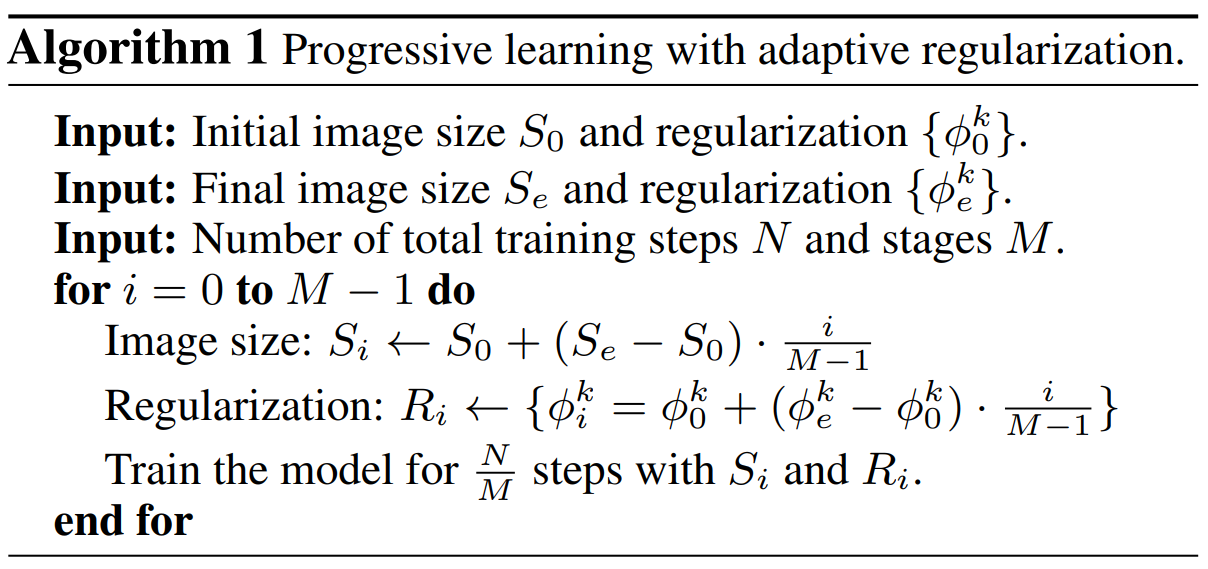

In [ ]:
import torch
import torchvision.transforms.functional as F